In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import linregress

plt.style.use("default")

In [3]:
nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")

scheme_perf = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")

benchmark = pd.read_csv("../data/processed/10_benchmark_indices_clean.csv")

In [4]:
print(nav.shape)
print(scheme_perf.shape)
print(benchmark.shape)

(46000, 3)
(40, 19)
(8050, 3)


In [5]:
print(nav.columns.tolist())

['amfi_code', 'date', 'nav']


In [6]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
).reset_index(drop=True)

In [7]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [8]:
nav.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [10]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

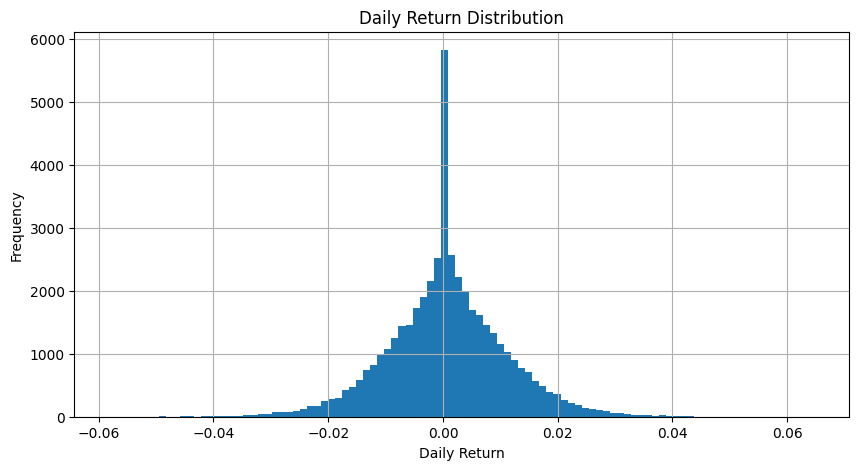

In [11]:
plt.figure(figsize=(10,5))

nav["daily_return"].dropna().hist(
    bins=100
)

plt.title("Daily Return Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

In [15]:
nav.to_csv(
    "../data/processed/nav_with_returns.csv",
    index=False
)

In [16]:
nav["daily_return"].describe()


count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

In [17]:
nav["date"].min(),
nav["date"].max()

Timestamp('2026-05-29 00:00:00')

In [19]:
def calculate_cagr(start_nav, end_nav, years):
    return (end_nav / start_nav) ** (1 / years) - 1

In [20]:
latest_date = nav["date"].max()

latest_date

Timestamp('2026-05-29 00:00:00')

In [21]:
cagr_results = []

for fund in nav["amfi_code"].unique():

    fund_data = nav[nav["amfi_code"] == fund].copy()

    end_date = fund_data["date"].max()

    end_nav = fund_data.iloc[-1]["nav"]

    row = {"amfi_code": fund}

    # 1 Year CAGR
    start_1y = end_date - pd.DateOffset(years=1)

    data_1y = fund_data[fund_data["date"] >= start_1y]

    if len(data_1y) > 0:
        start_nav = data_1y.iloc[0]["nav"]

        row["cagr_1y"] = calculate_cagr(
            start_nav,
            end_nav,
            1
        )
    else:
        row["cagr_1y"] = np.nan

    # 3 Year CAGR
    start_3y = end_date - pd.DateOffset(years=3)

    data_3y = fund_data[fund_data["date"] >= start_3y]

    if len(data_3y) > 0:
        start_nav = data_3y.iloc[0]["nav"]

        row["cagr_3y"] = calculate_cagr(
            start_nav,
            end_nav,
            3
        )
    else:
        row["cagr_3y"] = np.nan

    # 5 Year CAGR
    start_5y = end_date - pd.DateOffset(years=5)

    data_5y = fund_data[fund_data["date"] >= start_5y]

    if len(data_5y) > 1000:
        start_nav = data_5y.iloc[0]["nav"]

        row["cagr_5y"] = calculate_cagr(
            start_nav,
            end_nav,
            5
        )
    else:
        row["cagr_5y"] = np.nan

    cagr_results.append(row)

In [22]:
cagr_df = pd.DataFrame(cagr_results)

cagr_df.head()

,amfi_code,cagr_1y,cagr_3y,cagr_5y
0,100016,-0.022243,0.012926,0.023168
1,100025,0.037050,0.039164,0.039127
2,100033,0.532324,0.324425,0.260741
3,101206,0.479241,0.289677,0.204427
4,101207,-0.239860,-0.041524,0.069533


In [23]:
cagr_df = cagr_df.sort_values(
    "cagr_3y",
    ascending=False
)

cagr_df.head(10)

,amfi_code,cagr_1y,cagr_3y,cagr_5y
16,119094,0.222611,0.351118,0.244453
34,148567,0.203607,0.340009,0.267993
24,120504,0.130643,0.324874,0.202340
2,100033,0.532324,0.324425,0.260741
25,120505,0.296047,0.317775,0.283768
19,119551,0.604373,0.304565,0.223849
30,120843,0.266571,0.295828,0.267425
36,148569,0.397518,0.291789,0.276299
3,101206,0.479241,0.289677,0.204427
39,149324,0.651387,0.270004,0.279174


In [24]:
cagr_df.to_csv(
    "../data/processed/cagr_table.csv",
    index=False
)

In [26]:
RF = 0.065
daily_rf = RF / 252

In [27]:
sharpe_results = []

for fund in nav["amfi_code"].unique():

    fund_returns = nav.loc[
        nav["amfi_code"] == fund,
        "daily_return"
    ].dropna()

    mean_return = fund_returns.mean()

    std_return = fund_returns.std()

    sharpe = (
        (mean_return - daily_rf)
        / std_return
    ) * np.sqrt(252)

    sharpe_results.append({
        "amfi_code": fund,
        "sharpe_ratio": sharpe
    })

In [28]:
sharpe_df = pd.DataFrame(sharpe_results)

sharpe_df = sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
)

sharpe_df.head(10)

,amfi_code,sharpe_ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101
38,149323,1.132122
2,100033,1.093699
9,118632,1.081659
3,101206,1.027213
24,120504,1.026524


In [29]:
sharpe_df.to_csv(
    "../data/processed/sharpe_ratio.csv",
    index=False
)

In [30]:
sharpe_df.describe()

,amfi_code,sharpe_ratio
count,40.000000,40.000000
mean,120247.000000,0.537220
std,14534.998667,0.573689
min,100016.000000,-0.815567
25%,118632.750000,0.064696
50%,119551.500000,0.647043
75%,120842.250000,1.005304
max,149324.000000,1.448291


In [33]:
sortino_results = []

for fund in nav["amfi_code"].unique():

    fund_returns = nav.loc[
        nav["amfi_code"] == fund,
        "daily_return"
    ].dropna()

    downside_returns = fund_returns[
        fund_returns < 0
    ]

    downside_std = downside_returns.std()

    mean_return = fund_returns.mean()

    sortino = (
        (mean_return - daily_rf)
        / downside_std
    ) * np.sqrt(252)

    sortino_results.append({
        "amfi_code": fund,
        "sortino_ratio": sortino
    })

In [34]:
sortino_df = pd.DataFrame(sortino_results)

sortino_df = sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
)

sortino_df.head(10)

,amfi_code,sortino_ratio
34,148567,2.385644
30,120843,2.364320
36,148569,2.146914
19,119551,2.140267
25,120505,2.029353
38,149323,1.875101
9,118632,1.850133
2,100033,1.829134
24,120504,1.805294
3,101206,1.799563


In [35]:
sortino_df.to_csv(
    "../data/processed/sortino_ratio.csv",
    index=False
)

In [36]:
sortino_df["sortino_ratio"].describe()

count    40.000000
mean      0.923338
std       1.005410
min      -1.681038
25%       0.106664
50%       1.116936
75%       1.727739
max       2.385644
Name: sortino_ratio, dtype: float64

In [39]:
print(benchmark.columns.tolist())
print(benchmark.head())

['date', 'index_name', 'close_value']
         date index_name  close_value
0  2022-01-03    NIFTY50     17492.79
1  2022-01-04    NIFTY50     17689.64
2  2022-01-05    NIFTY50     17835.05
3  2022-01-06    NIFTY50     17878.51
4  2022-01-07    NIFTY50     17759.15


In [40]:
benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

In [41]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

In [42]:
nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

In [43]:
nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [44]:
alpha_beta_results = []

In [45]:
for fund in nav["amfi_code"].unique():

    fund_data = nav[
        ["amfi_code", "date", "daily_return"]
    ].copy()

    fund_data = fund_data[
        fund_data["amfi_code"] == fund
    ]

    merged = pd.merge(
        fund_data,
        nifty100[
            ["date", "benchmark_return"]
        ],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) > 30:

        regression = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        beta = regression.slope

        alpha = regression.intercept * 252

        alpha_beta_results.append({
            "amfi_code": fund,
            "alpha": alpha,
            "beta": beta,
            "r_squared": regression.rvalue ** 2
        })

In [46]:
alpha_beta_df = pd.DataFrame(
    alpha_beta_results
)

alpha_beta_df.head()

,amfi_code,alpha,beta,r_squared
0,100016,0.037476,-0.058268,0.002665
1,100025,0.042818,0.001158,0.000015
2,100033,0.271954,0.005104,0.000012
3,101206,0.213998,0.021086,0.000348
4,101207,0.108971,-0.065289,0.001064


In [47]:
alpha_beta_df = alpha_beta_df.sort_values(
    "alpha",
    ascending=False
)

alpha_beta_df.head(10)

,amfi_code,alpha,beta,r_squared
21,119598,0.303370,-0.023196,1.414258e-04
39,149324,0.300579,0.011455,3.532991e-05
25,120505,0.292636,0.000549,1.345534e-07
36,148569,0.282704,0.018134,1.748889e-04
30,120843,0.273305,-0.022830,3.430543e-04
2,100033,0.271954,0.005104,1.206652e-05
34,148567,0.269838,0.023684,4.625437e-04
38,149323,0.265986,-0.002523,3.357978e-06
16,119094,0.260767,-0.066265,1.936879e-03
19,119551,0.232010,-0.031751,8.869789e-04


In [48]:
alpha_beta_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

In [49]:
alpha_beta_df.describe()

,amfi_code,alpha,beta,r_squared
count,40.000000,40.000000,40.000000,4.000000e+01
mean,120247.000000,0.159085,-0.001958,6.087700e-04
std,14534.998667,0.087528,0.035194,7.265363e-04
min,100016.000000,0.028969,-0.066951,1.345534e-07
25%,118632.750000,0.068612,-0.023937,5.495723e-05
50%,119551.500000,0.162326,-0.000067,3.455513e-04
75%,120842.250000,0.221723,0.017026,1.035467e-03
max,149324.000000,0.303370,0.103497,2.793007e-03


In [51]:
drawdown_results = []

In [57]:
drawdown_results = []

for fund in nav["amfi_code"].unique():

    fund_data = nav[
        nav["amfi_code"] == fund
    ].copy()

    fund_data = fund_data.sort_values("date")

    fund_data["running_max"] = (
        fund_data["nav"].cummax()
    )

    fund_data["drawdown"] = (
        fund_data["nav"]
        / fund_data["running_max"]
        - 1
    )

    trough_idx = fund_data["drawdown"].idxmin()

    trough_date = fund_data.loc[
        trough_idx,
        "date"
    ]

    peak_date = fund_data.loc[
        :trough_idx,
        "nav"
    ].idxmax()

    peak_date = fund_data.loc[
        peak_date,
        "date"
    ]

    drawdown_results.append({
        "amfi_code": fund,
        "max_drawdown":
            fund_data["drawdown"].min(),
        "peak_date": peak_date,
        "trough_date": trough_date
    })

In [58]:
drawdown_df = pd.DataFrame(
    drawdown_results
)

drawdown_df.head()

,amfi_code,max_drawdown,peak_date,trough_date
0,100016,-0.247344,2022-03-30,2022-09-15
1,100025,-0.043083,2023-05-23,2023-07-28
2,100033,-0.162172,2022-03-11,2022-05-12
3,101206,-0.112916,2023-04-24,2023-07-05
4,101207,-0.354469,2024-11-21,2026-05-11


In [54]:
drawdown_df = drawdown_df.sort_values(
    "max_drawdown"
)

drawdown_df.head(10)

,amfi_code,max_drawdown,worst_date
22,119599,-0.525742,2025-10-28
17,119095,-0.516778,2026-05-11
4,101207,-0.354469,2026-05-11
39,149324,-0.311719,2025-01-03
21,119598,-0.287060,2025-05-14
7,102886,-0.280011,2026-04-27
0,100016,-0.247344,2022-09-15
29,120842,-0.240035,2024-10-17
11,118634,-0.233449,2026-02-20
15,119093,-0.217514,2023-05-22


In [59]:
drawdown_df.to_csv(
    "../data/processed/max_drawdown.csv",
    index=False
)

In [60]:
drawdown_df.describe()

,amfi_code,max_drawdown,peak_date,trough_date
count,40.000000,40.000000,40,40
mean,120247.000000,-0.178729,2023-08-12 18:36:00,2024-03-12 18:00:00
min,100016.000000,-0.525742,2022-01-03 00:00:00,2022-02-04 00:00:00
25%,118632.750000,-0.215927,2022-09-04 00:00:00,2023-05-28 00:00:00
50%,119551.500000,-0.163070,2023-09-05 00:00:00,2024-02-07 00:00:00
75%,120842.250000,-0.117653,2024-05-07 12:00:00,2025-02-08 18:00:00
max,149324.000000,-0.000977,2025-10-16 00:00:00,2026-05-11 00:00:00
std,14534.998667,0.112686,NaN,NaN


In [63]:
scorecard = cagr_df[
    ["amfi_code", "cagr_3y"]
].copy()

scorecard = scorecard.merge(
    sharpe_df,
    on="amfi_code"
)

scorecard = scorecard.merge(
    alpha_beta_df[
        ["amfi_code", "alpha"]
    ],
    on="amfi_code"
)

scorecard = scorecard.merge(
    drawdown_df[
        ["amfi_code", "max_drawdown"]
    ],
    on="amfi_code"
)

scorecard = scorecard.merge(
    scheme_perf[
        ["amfi_code", "expense_ratio_pct"]
    ],
    on="amfi_code"
)

scorecard.head()

,amfi_code,cagr_3y,sharpe_ratio,alpha,max_drawdown,expense_ratio_pct
0,119094,0.351118,0.998231,0.260767,-0.209609,1.38
1,148567,0.340009,1.448291,0.269838,-0.112657,1.46
2,120504,0.324874,1.026524,0.211948,-0.125883,0.80
3,100033,0.324425,1.093699,0.271954,-0.162172,1.38
4,120505,0.317775,1.180101,0.292636,-0.181885,1.36


In [64]:
scorecard["cagr_rank"] = (
    scorecard["cagr_3y"]
    .rank(ascending=False)
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(ascending=False)
)

scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(ascending=False)
)

scorecard["expense_rank"] = (
    scorecard["expense_ratio_pct"]
    .rank(ascending=True)
)

scorecard["drawdown_rank"] = (
    scorecard["max_drawdown"]
    .rank(ascending=False)
)

In [65]:
n = len(scorecard)

for col in [
    "cagr_rank",
    "sharpe_rank",
    "alpha_rank",
    "expense_rank",
    "drawdown_rank"
]:
    scorecard[col + "_score"] = (
        (n - scorecard[col])
        / (n - 1)
    ) * 100

In [66]:
scorecard["fund_score"] = (

    scorecard["cagr_rank_score"] * 0.30 +

    scorecard["sharpe_rank_score"] * 0.25 +

    scorecard["alpha_rank_score"] * 0.20 +

    scorecard["expense_rank_score"] * 0.15 +

    scorecard["drawdown_rank_score"] * 0.10
)

In [67]:
scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
)

scorecard.head(10)

,amfi_code,cagr_3y,sharpe_ratio,alpha,max_drawdown,expense_ratio_pct,cagr_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,cagr_rank_score,sharpe_rank_score,alpha_rank_score,expense_rank_score,drawdown_rank_score,fund_score
1,148567,0.340009,1.448291,0.269838,-0.112657,1.46,2.0,1.0,7.0,23.0,8.0,97.435897,100.000000,84.615385,43.589744,82.051282,85.897436
4,120505,0.317775,1.180101,0.292636,-0.181885,1.36,5.0,5.0,3.0,15.0,25.0,89.743590,89.743590,94.871795,64.102564,38.461538,81.794872
6,120843,0.295828,1.306744,0.273305,-0.129740,1.45,7.0,2.0,5.0,22.0,13.0,84.615385,97.435897,89.743590,46.153846,69.230769,81.538462
3,100033,0.324425,1.093699,0.271954,-0.162172,1.38,4.0,7.0,6.0,17.0,20.0,92.307692,84.615385,87.179487,58.974359,51.282051,80.256410
2,120504,0.324874,1.026524,0.211948,-0.125883,0.80,3.0,10.0,13.0,12.0,12.0,94.871795,76.923077,69.230769,71.794872,71.794872,79.487179
0,119094,0.351118,0.998231,0.260767,-0.209609,1.38,1.0,11.0,9.0,17.0,28.0,100.000000,74.358974,79.487179,58.974359,30.769231,76.410256
5,119551,0.304565,1.208267,0.232010,-0.150124,1.54,6.0,4.0,10.0,30.5,17.0,87.179487,92.307692,76.923077,24.358974,58.974359,74.166667
7,148569,0.291789,1.234930,0.282704,-0.163967,1.60,8.0,3.0,4.0,36.5,21.0,82.051282,94.871795,92.307692,8.974359,48.717949,73.012821
8,101206,0.289677,1.027213,0.213998,-0.112916,1.60,9.0,9.0,12.0,36.5,9.0,79.487179,79.487179,71.794872,8.974359,79.487179,67.371795
11,119598,0.266699,0.945308,0.303370,-0.287060,1.43,12.0,14.0,1.0,21.0,36.0,71.794872,66.666667,100.000000,48.717949,10.256410,66.538462


In [68]:
scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

In [70]:
top5_funds = scorecard.head(5)["amfi_code"].tolist()

top5_funds

[148567, 120505, 120843, 100033, 120504]

In [71]:
benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy()

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

In [72]:
end_date = nav["date"].max()

start_date = end_date - pd.DateOffset(years=3)

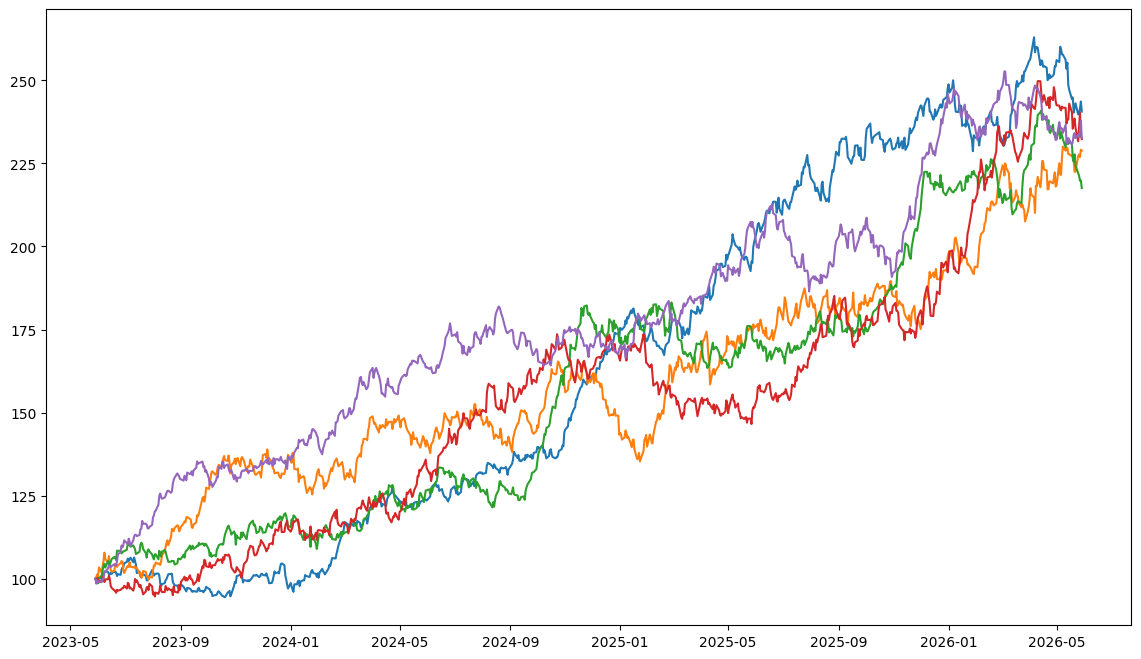

In [73]:
plt.figure(figsize=(14,8))

for fund in top5_funds:

    fund_data = nav[
        nav["amfi_code"] == fund
    ].copy()

    fund_data = fund_data[
        fund_data["date"] >= start_date
    ]

    base_nav = fund_data.iloc[0]["nav"]

    normalized = (
        fund_data["nav"] / base_nav
    ) * 100

    plt.plot(
        fund_data["date"],
        normalized,
        label=f"Fund {fund}"
    )

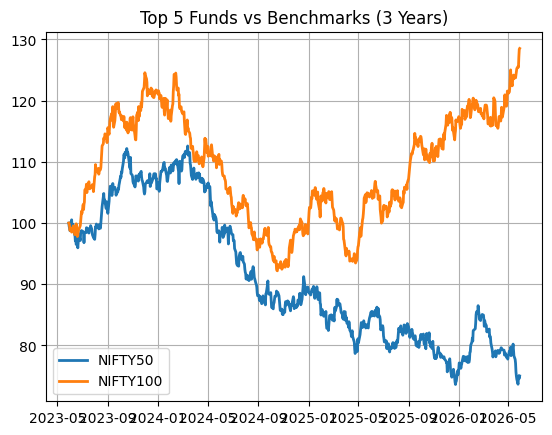

In [74]:
n50 = nifty50[
    nifty50["date"] >= start_date
].copy()

n100 = nifty100[
    nifty100["date"] >= start_date
].copy()

n50_norm = (
    n50["close_value"]
    / n50.iloc[0]["close_value"]
) * 100

n100_norm = (
    n100["close_value"]
    / n100.iloc[0]["close_value"]
) * 100

plt.plot(
    n50["date"],
    n50_norm,
    linewidth=2,
    label="NIFTY50"
)

plt.plot(
    n100["date"],
    n100_norm,
    linewidth=2,
    label="NIFTY100"
)

plt.title(
    "Top 5 Funds vs Benchmarks (3 Years)"
)

plt.legend()

plt.grid(True)

plt.show()

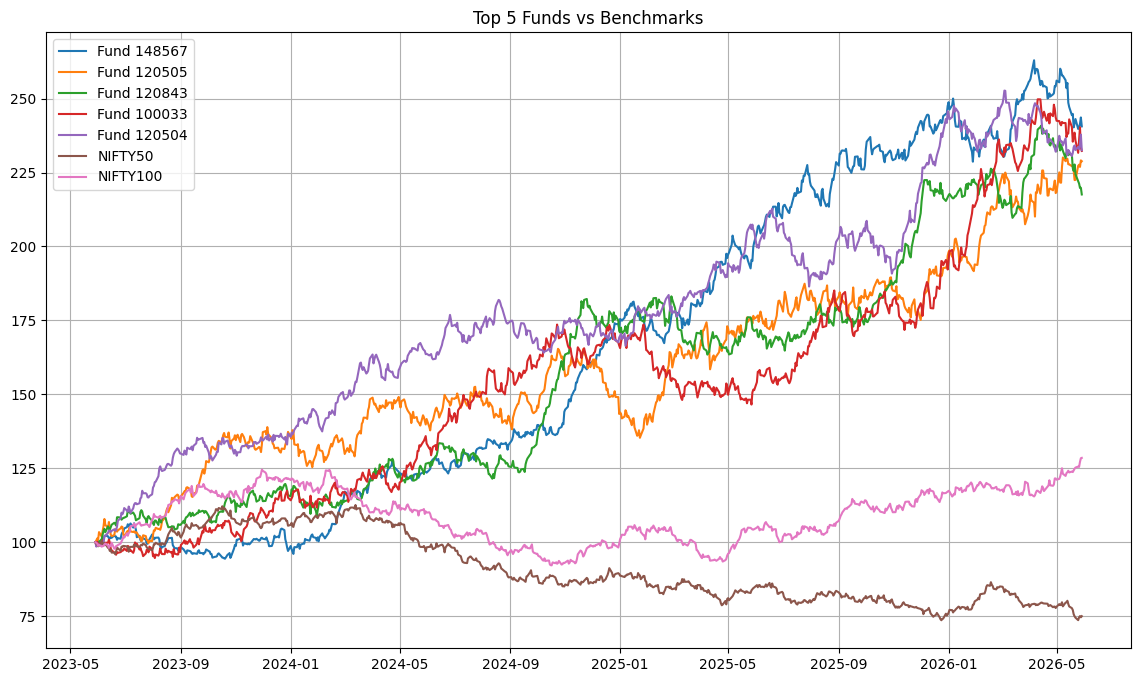

In [75]:
plt.figure(figsize=(14,8))

for fund in top5_funds:

    fund_data = nav[
        nav["amfi_code"] == fund
    ].copy()

    fund_data = fund_data[
        fund_data["date"] >= start_date
    ]

    norm = (
        fund_data["nav"]
        / fund_data.iloc[0]["nav"]
    ) * 100

    plt.plot(
        fund_data["date"],
        norm,
        label=f"Fund {fund}"
    )

plt.plot(
    n50["date"],
    n50_norm,
    label="NIFTY50"
)

plt.plot(
    n100["date"],
    n100_norm,
    label="NIFTY100"
)

plt.title(
    "Top 5 Funds vs Benchmarks"
)

plt.legend()

plt.grid(True)

plt.savefig(
    "../reports/benchmark_comparison.png",
    bbox_inches="tight"
)

plt.show()

In [76]:
tracking_results = []

In [81]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"].pct_change()
)

print(nifty100.columns.tolist())

['date', 'index_name', 'close_value', 'benchmark_return']


In [83]:
benchmark_returns = nifty100[
    ["date", "benchmark_return"]
].copy()

In [84]:
merged = pd.merge(
    fund_data,
    benchmark_returns,
    on="date",
    how="inner"
)

In [85]:
print(nifty100[["date","benchmark_return"]].head())

           date  benchmark_return
1150 2022-01-03               NaN
1151 2022-01-04         -0.013540
1152 2022-01-05          0.004003
1153 2022-01-06         -0.002935
1154 2022-01-07          0.006150


In [87]:
benchmark_returns = nifty100[
    ["date", "benchmark_return"]
].copy()

print(benchmark_returns.head())

           date  benchmark_return
1150 2022-01-03               NaN
1151 2022-01-04         -0.013540
1152 2022-01-05          0.004003
1153 2022-01-06         -0.002935
1154 2022-01-07          0.006150


In [88]:
tracking_results = []

for fund in nav["amfi_code"].unique():

    fund_data = nav[
        ["date", "amfi_code", "daily_return"]
    ]

    fund_data = fund_data[
        fund_data["amfi_code"] == fund
    ]

    merged = pd.merge(
        fund_data,
        benchmark_returns,
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    tracking_error = (
        (
            merged["daily_return"]
            - merged["benchmark_return"]
        ).std()
        * np.sqrt(252)
    )

    tracking_results.append({
        "amfi_code": fund,
        "tracking_error": tracking_error
    })

tracking_df = pd.DataFrame(tracking_results)

tracking_df.sort_values(
    "tracking_error"
).head()

,amfi_code,tracking_error
5,101208,0.128957
27,120507,0.129044
31,120844,0.129046
1,100025,0.134535
13,118636,0.134758


In [89]:
tracking_df.to_csv(
    "../data/processed/tracking_error.csv",
    index=False
)